# Modeling
CRISP-DM modeling stage for `review_concern`.



In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents) if (path / "pipeline").exists()
)
sys.path.insert(0, str(PROJECT_ROOT))

from pipeline.modeling import train_and_evaluate

DATASET_VERSION = "dataset_modeling_v0.2"
DATA_DIR = PROJECT_ROOT / "data/processed/modeling_v0.2"
REPORT_DIR = PROJECT_ROOT / "reports/modeling_v0.2"
FIGURE_DIR = PROJECT_ROOT / "figures/modeling"
RUN_MODELING = False

if RUN_MODELING:
    train_and_evaluate(
        data_dir=DATA_DIR,
        dataset_version=DATASET_VERSION,
        report_dir=REPORT_DIR,
        figure_dir=FIGURE_DIR,
    )



## Select Modeling Technique
Models are compared against a majority-class baseline. The trained candidates
are logistic regression and XGBoost, each with tabular-only and full
tabular-plus-embedding feature sets.



In [2]:
summary = json.loads((REPORT_DIR / "modeling_summary.json").read_text())
metrics = pd.read_csv(REPORT_DIR / "modeling_metrics.csv")
metrics[
    [
        "model",
        "feature_set",
        "feature_count",
        "val_roc_auc",
        "val_average_precision",
        "val_macro_f1",
        "val_balanced_accuracy",
        "val_threshold",
    ]
]



,model,feature_set,feature_count,val_roc_auc,val_average_precision,val_macro_f1,val_balanced_accuracy,val_threshold
0,xgboost_all_features,all,802,0.638490,0.975848,0.532156,0.532156,0.407010
1,logistic_all_features,all,802,0.598935,0.973162,0.516665,0.521774,0.080621
2,xgboost_tabular,tabular,34,0.566737,0.969160,0.505804,0.508407,0.333394
3,logistic_tabular,tabular,34,0.538994,0.965375,0.510544,0.516856,0.336310
4,majority_baseline,none,0,0.500000,0.959119,0.489567,0.500000,0.500000


## Generate Test Design
Repository-level train/validation/test splits are inherited from data
preparation. Model selection uses validation ROC-AUC; the selected threshold
maximizes validation macro-F1.



In [3]:
summary["class_balance"], summary["selected_model"], summary["selected_threshold"]



({'train': [367, 7689], 'val': [39, 915], 'test': [40, 941]},
 'xgboost_all_features',
 0.4070095241069794)

## Build Model
The best validation model is assessed on the held-out test split with the threshold selected on validation macro-F1.



In [4]:
print((REPORT_DIR / "selected_test_classification_report.txt").read_text())



Selected test: xgboost_all_features
threshold=0.407010
              precision    recall  f1-score   support

           0     0.1176    0.1000    0.1081        40
           1     0.9620    0.9681    0.9650       941

    accuracy                         0.9327       981
   macro avg     0.5398    0.5341    0.5366       981
weighted avg     0.9276    0.9327    0.9301       981

confusion_matrix=[[4, 36], [30, 911]]



## Assess Model
Validation plots and selected-model diagnostics are shown below.



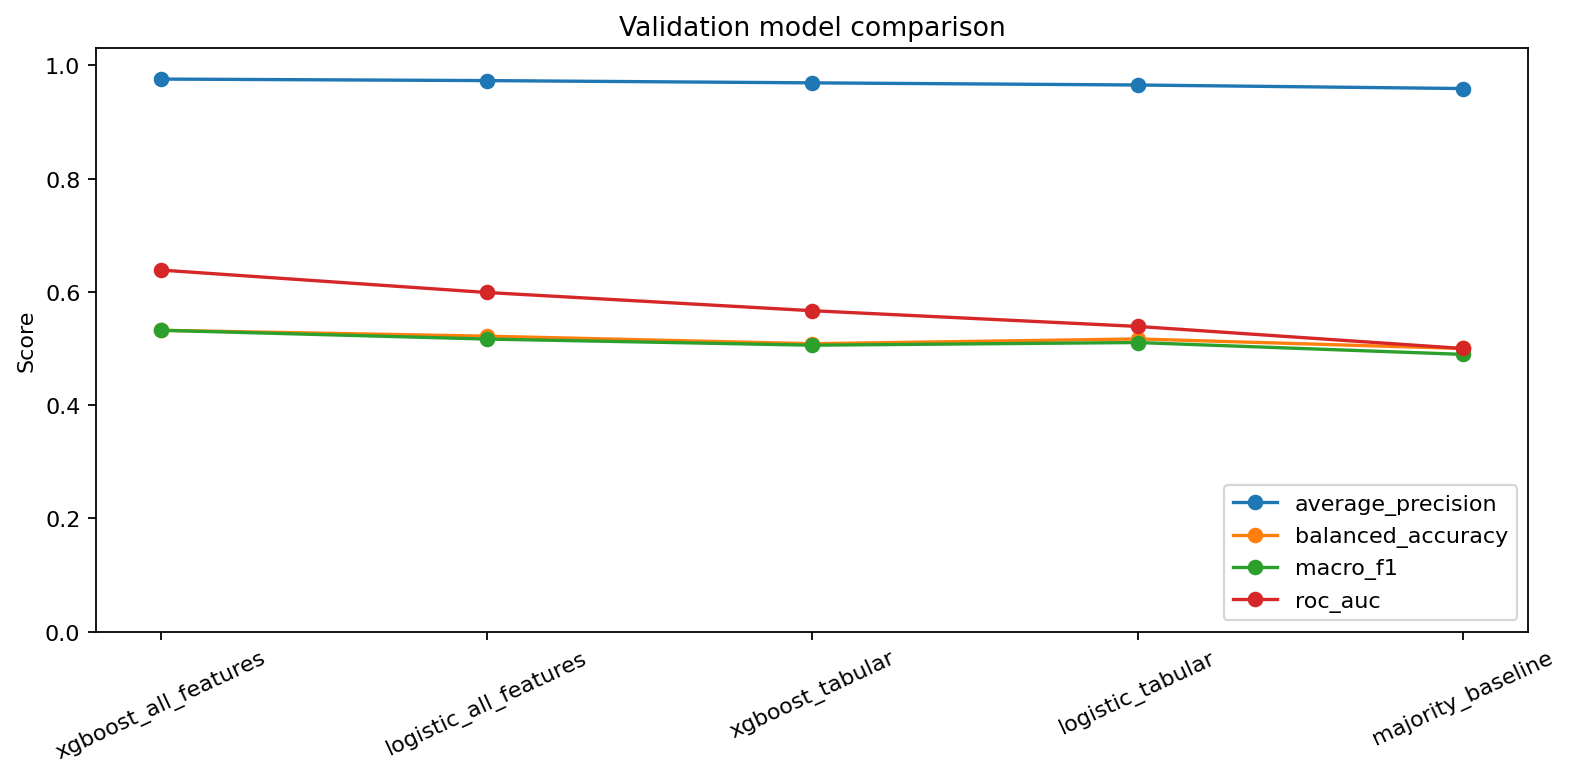

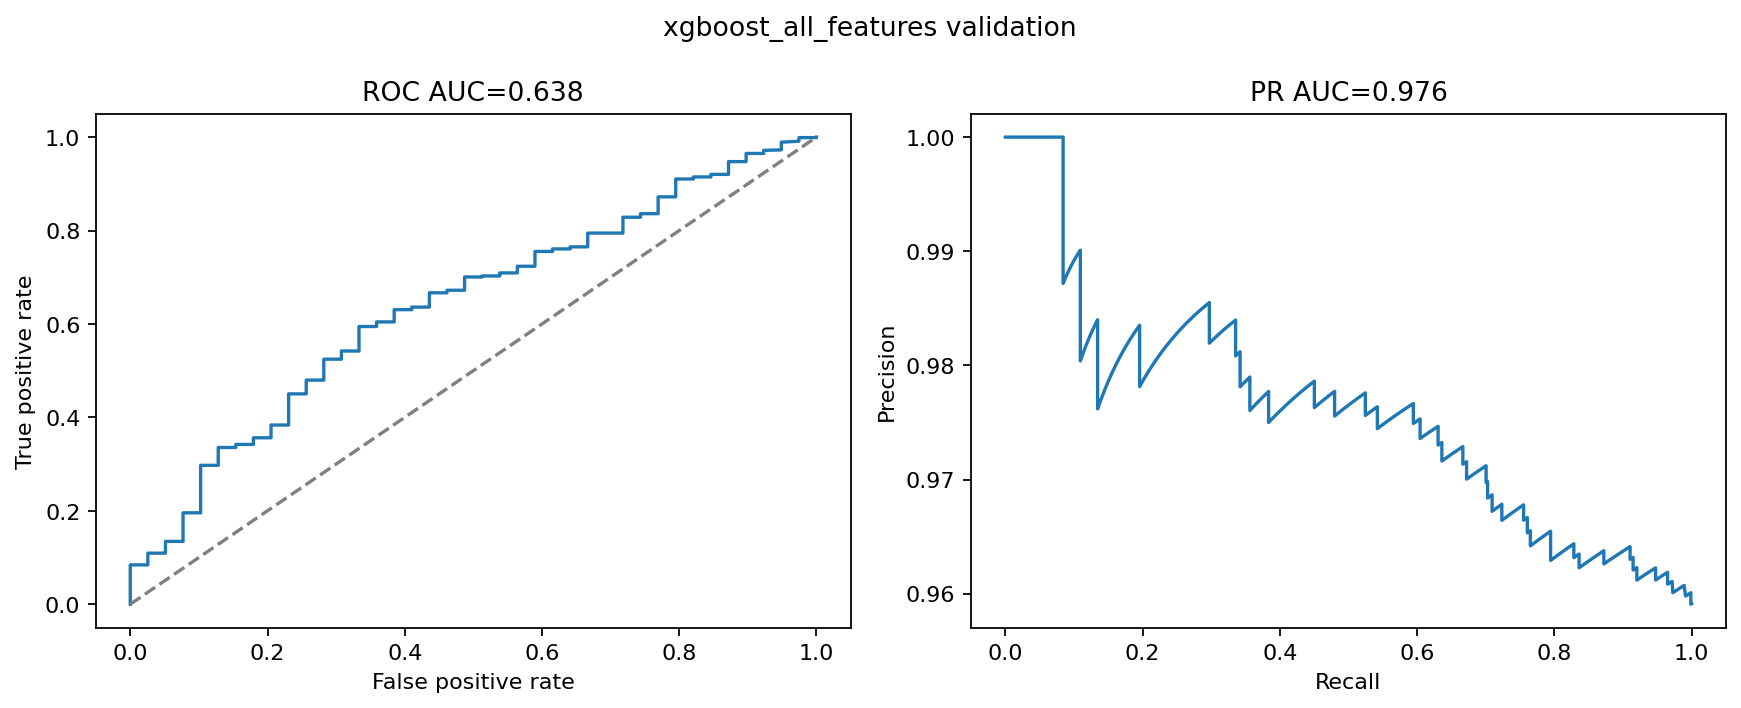

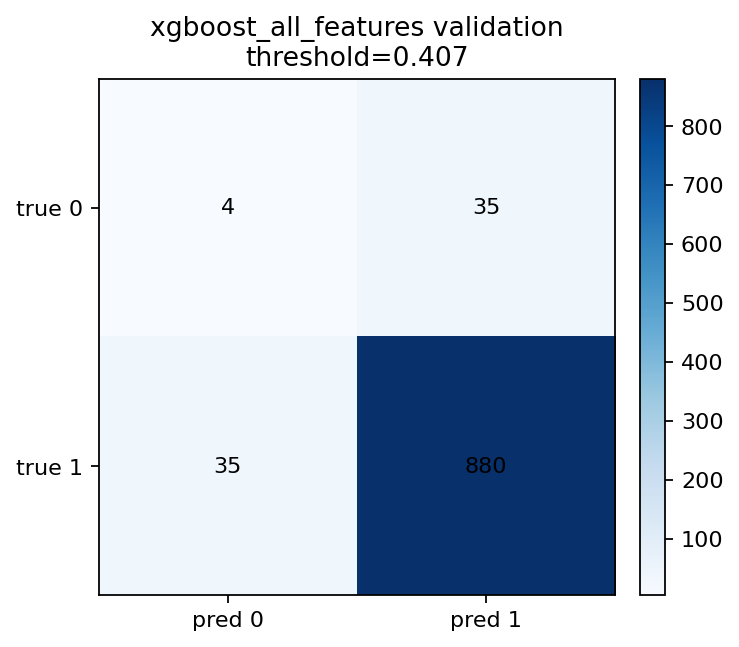

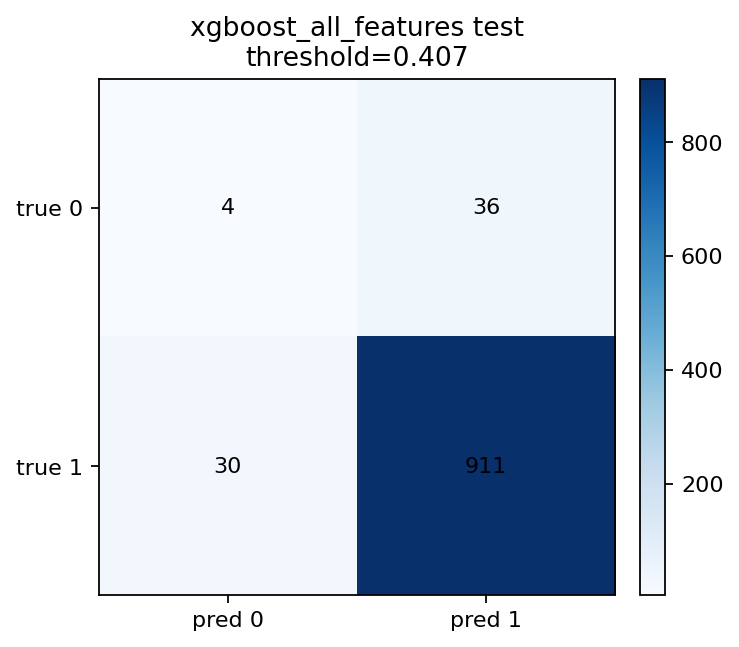

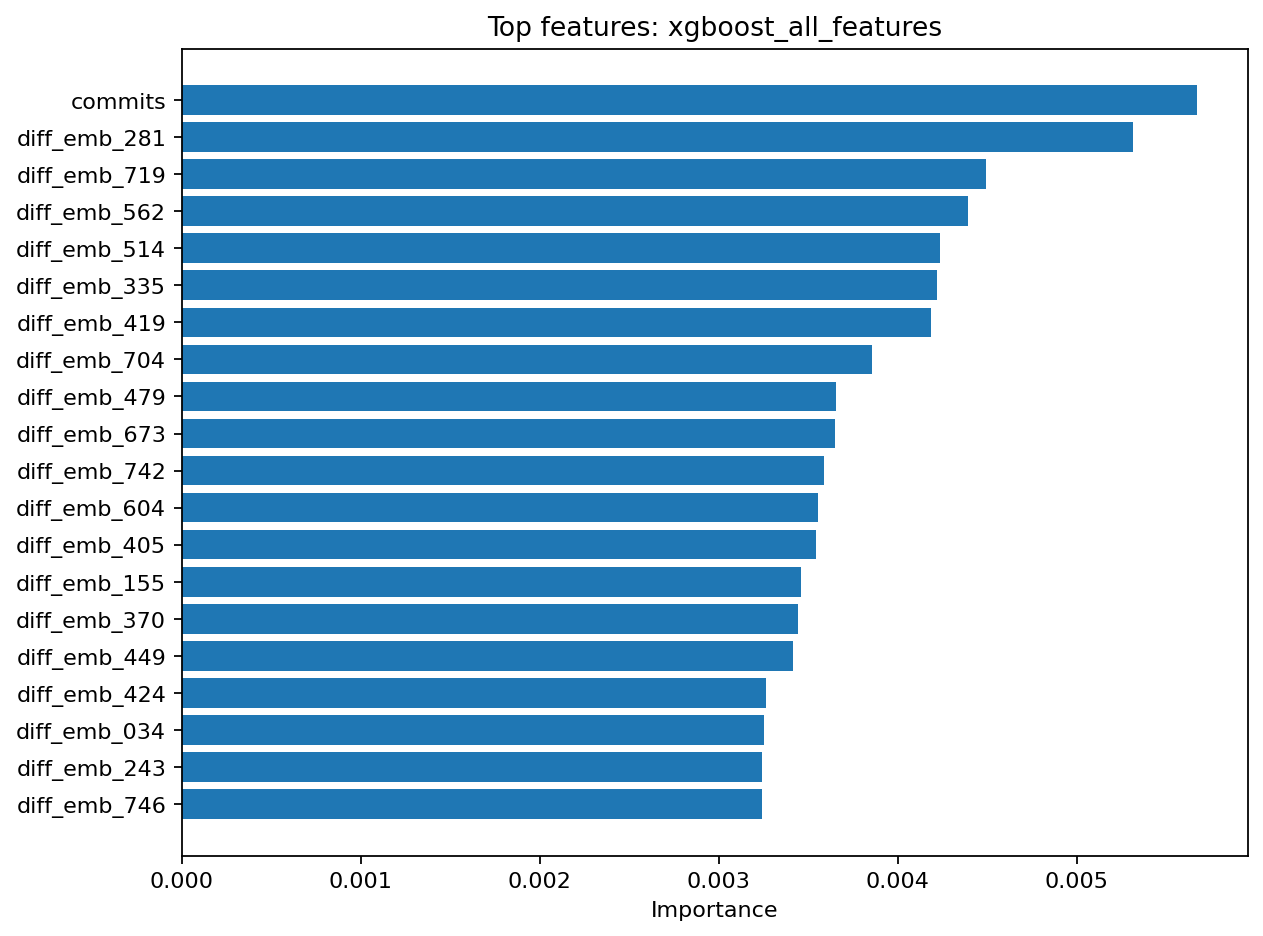

In [5]:
for name in [
    "model_comparison_validation.png",
    "selected_validation_curves.png",
    "selected_validation_confusion.png",
    "selected_test_confusion.png",
    "selected_feature_importance.png",
]:
    display(Image(filename=str(FIGURE_DIR / name)))
